# Natural Language Processing: Dwelling Permit Data

## Preliminaries

In [116]:
# Imports

# General
import numpy as np
import pandas as pd
import json
import itertools
import time
from IPython.display import display
import random
from joblib import Memory
from datetime import datetime
import csv

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'iframe' # For plotly graphs to render in this environment

# Geography
import geopandas as gpd
from shapely.geometry import Point, Polygon


# NLP
import re
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer, TfidfVectorizer
import nltk, pprint
pprint.pp(nltk.data.path)
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet as wn
from nltk.corpus import names
import pycountry

# sk-learn modeling
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.model_selection import ParameterGrid
from sklearn.decomposition import TruncatedSVD
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.base import clone
from sklearn.metrics import (
        silhouette_score,
        silhouette_samples,
        davies_bouldin_score, 
        calinski_harabasz_score)


['C:\\Users\\emshe/nltk_data',
 'C:\\Users\\emshe\\anaconda3\\envs\\capstone_env\\nltk_data',
 'C:\\Users\\emshe\\anaconda3\\envs\\capstone_env\\share\\nltk_data',
 'C:\\Users\\emshe\\anaconda3\\envs\\capstone_env\\lib\\nltk_data',
 'C:\\Users\\emshe\\AppData\\Roaming\\nltk_data',
 'C:\\nltk_data',
 'D:\\nltk_data',
 'E:\\nltk_data']


In [2]:
# Install extras for nltk (run once)


# nltk.download("averaged_perceptron_tagger")
# nltk.download('averaged_perceptron_tagger_eng')
# nltk.download('wordnet')
# nltk.download('omw-1.4')  # extra lemmas
# nltk.download("names") # List of names

In [9]:
# Load permits data

permits_df = pd.read_csv(f"{PATH}/PERMITS/issued_building_permits_filter_dwelling_purposes_preprocessed.csv")

examine_df('permits dataframe',permits_df)



Number of records in the permits dataframe is: 25417



Number of features in the permits dataframe is: 19

The columns in the permits dataframe are: Index(['issue_date', 'project_description', 'geom', 'project_value', 'nbhd',
       'zone', 'duplex_w_secondary_suite', 'laneway_house', 'duplex',
       'multiple_conversion_dwelling', 'dwelling_unit', 'multiple_dwelling',
       'single_detached_house', 'single_detached_house_w_sec_suite',
       'type_of_work_demolition_deconstruction', 'type_of_work_new_building',
       'permit_category_new_build_low_density_housing',
       'permit_category_new_build_standalone_laneway',
       'permit_category_renovation_residential_lower_complexity'],
      dtype='object')


 Other info about permits dataframe:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25417 entries, 0 to 25416
Data columns (total 19 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                               

None


 Basic statistical info about permits dataframe:



,project_value,duplex_w_secondary_suite,laneway_house,duplex,multiple_conversion_dwelling,dwelling_unit,multiple_dwelling,single_detached_house,single_detached_house_w_sec_suite,type_of_work_demolition_deconstruction,type_of_work_new_building,permit_category_new_build_low_density_housing,permit_category_new_build_standalone_laneway,permit_category_renovation_residential_lower_complexity
count,2.541700e+04,25417.000000,25417.000000,25417.000000,25417.000000,25417.000000,25417.000000,25417.000000,25417.000000,25417.000000,25417.000000,25417.000000,25417.000000,25417.000000
mean,8.814701e+05,0.026754,0.148601,0.058937,0.013456,0.023528,0.210725,0.319432,0.181650,0.224810,0.372349,0.257820,0.079278,0.309832
std,9.295619e+06,0.161366,0.355702,0.235511,0.115217,0.151575,0.407832,0.466266,0.385563,0.417465,0.483440,0.437443,0.270177,0.462433
min,5.053050e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.749044e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.010610e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.078863e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000
max,8.408412e+08,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000




Sample of records in the permits dataframe:


,issue_date,project_description,geom,project_value,nbhd,zone,duplex_w_secondary_suite,laneway_house,duplex,multiple_conversion_dwelling,dwelling_unit,multiple_dwelling,single_detached_house,single_detached_house_w_sec_suite,type_of_work_demolition_deconstruction,type_of_work_new_building,permit_category_new_build_low_density_housing,permit_category_new_build_standalone_laneway,permit_category_renovation_residential_lower_complexity
0,2017-04-12,Low Density Housing - New Building - To constr...,POINT (-123.0438851 49.2545202),250115.294118,Renfrew,Mount Pleasant/Renfrew Heights,0,0,0,0,0,0,0,1,0,1,1,0,0
1,2022-11-14,Low Density Housing - Demolition / Deconstruct...,POINT (-123.0677731 49.2249324),15625.427204,Fraser View/Killarny,Southeast Vancouver,0,0,0,0,0,0,1,0,1,0,0,0,0
2,2017-08-23,Field Review - Demolition / Deconstruction - T...,POINT (-123.1211653 49.2588709),75669.289412,South Granville,South Granville/Oak,0,0,0,0,0,1,0,0,1,0,0,0,0
3,2017-09-28,Low Density Housing - New Building - To constr...,POINT (-123.0846679 49.2365573),183866.117647,Sunset,Southeast Vancouver,0,1,0,0,0,0,0,0,0,1,0,1,0
4,2018-08-03,Low Density Housing - Demolition / Deconstruct...,POINT (-123.0894871 49.239411),17490.436113,Sunset,Southeast Vancouver,0,0,0,0,0,0,0,1,1,0,0,0,0


## Define helper functions

In [5]:
# Define function to examine dataframes

def examine_df(name,df,
               include_stats = True,
               include_sample = True):
    
    """
    Check basic info about a dataframe df
    """
    
    print(f"\n\nNumber of records in the {name} is: {len(df)}\n")
    print(f"\n\nNumber of features in the {name} is: {len(df.columns)}\n")
    print(f"The columns in the {name} are: {df.columns}\n")
    print(f"\n Other info about {name}:\n")
    display(df.info())
    if include_stats == True:
        print(f'\n Basic statistical info about {name}:\n')
        display(df.describe())
    if include_sample == True:
        print(f"\n\nSample of records in the {name}:")
        display(df.head(5))

In [6]:
# Define functions to detect binary columns vs. continuous functions

def is_binary(series: pd.Series) -> bool:

    '''
    Detect binary columns in series
    '''
    
    vals = series.dropna().unique()
    return set(vals).issubset({0, 1}) and len(vals) <= 2

def select_binary_cols(X):

    '''
    Select subset of binary columns
    '''
    
    return [c for c in X.columns
            if c != "project_description"
            and is_binary(X[c])]

def select_cont_cols(X):

    '''
    Select subset of continuous columns
    '''
    
    cols = []
    for c in X.columns:
        if c == "project_description":
            continue
        s = X[c]
        # numeric dtype
        if np.issubdtype(s.dtype, np.number):
            if not is_binary(s):
                cols.append(c)
    return cols

In [7]:
# Define function to drop trivial columns from dataframe

def drop_trivial(df):

    """
    Drop all trivial (all 1 or all 0) columns from a dataframe
    """

    n_rows = len(df)
    
    to_drop = []

    for col in df.columns:
        if is_binary(df[col]) and (df[col].sum() == 0 or df[col].sum() == n_rows):
            to_drop.append(col)

    df = df.drop(columns = to_drop)
    return df

In [8]:
# Define function to make permit sub-dataframe model ready

def model_ready(df):

    """
    Drop columns that won't be used in modeling
    """

    return df.drop(columns = ['issue_date', 'geom','nbhd','zone'])

## Split Up Permits

In [32]:
# Get dataframes of new builds (one with all info, one for modeling)

is_new_building = (permits_df['type_of_work_new_building'] == 1) | (permits_df['permit_category_new_build_low_density_housing'] == 1) | (permits_df['permit_category_new_build_standalone_laneway'] == 1)

builds_df = permits_df[is_new_building]

builds_df = drop_trivial(builds_df)

cluster_builds_df = model_ready(builds_df)

examine_df('builds dataframe', cluster_builds_df)



Number of records in the builds dataframe is: 9464



Number of features in the builds dataframe is: 12

The columns in the builds dataframe are: Index(['project_description', 'project_value', 'duplex_w_secondary_suite',
       'laneway_house', 'duplex', 'multiple_conversion_dwelling',
       'dwelling_unit', 'multiple_dwelling', 'single_detached_house',
       'single_detached_house_w_sec_suite',
       'permit_category_new_build_low_density_housing',
       'permit_category_new_build_standalone_laneway'],
      dtype='object')


 Other info about builds dataframe:

<class 'pandas.core.frame.DataFrame'>
Index: 9464 entries, 0 to 25414
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   project_description                            9464 non-null   object 
 1   project_value                                  9464 non-null   float64
 2   duplex_w_sec

None


 Basic statistical info about builds dataframe:



,project_value,duplex_w_secondary_suite,laneway_house,duplex,multiple_conversion_dwelling,dwelling_unit,multiple_dwelling,single_detached_house,single_detached_house_w_sec_suite,permit_category_new_build_low_density_housing,permit_category_new_build_standalone_laneway
count,9.464000e+03,9464.000000,9464.000000,9464.000000,9464.000000,9464.000000,9464.000000,9464.000000,9464.000000,9464.000000,9464.000000
mean,2.130362e+06,0.059277,0.392434,0.096682,0.001162,0.004121,0.064138,0.137997,0.225592,0.692413,0.212912
std,1.512969e+07,0.236155,0.488318,0.295540,0.034074,0.064065,0.245011,0.344915,0.417993,0.461519,0.409388
min,1.019777e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.388613e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.070169e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,9.785543e+05,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,8.408412e+08,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000




Sample of records in the builds dataframe:


,project_description,project_value,duplex_w_secondary_suite,laneway_house,duplex,multiple_conversion_dwelling,dwelling_unit,multiple_dwelling,single_detached_house,single_detached_house_w_sec_suite,permit_category_new_build_low_density_housing,permit_category_new_build_standalone_laneway
0,"Low Density Housing - New Building - To construct a 2 storey laneway house building \nproviding 1 on grade parking space, having vehicular access \nfrom the lane. \n \n1. No A/C unit proposed \n \nNote: Bldg 1 (principal bldg) addressed 3286 Renfrew St retained on site.",2.501153e+05,0,0,0,0,0,0,0,1,1,0
3,"Low Density Housing - New Building - To construct a 2 storey laneway house building providing 1 on grade parking space, having vehicular access from the lane. \n \n1. No A/C unit proposed \n2. B1/B2. E.H.Y. Man P.Eng (604-874-3237) Structural\n3. HPO - JET Demolition & Excavating Ltd. \n \n******THIS PERMIT HAS BEEN ISSUED UNDER THE REQUIREMENTS OF VBBL 2014***** \n \nNote: Bldg 1 (principal bldg) addressed 1004 E 37th Av retained on site.",1.838661e+05,0,1,0,0,0,0,0,0,0,1
14,"Low Density Housing - New Building - To construct a 2 storey + cellar one-family dwelling with a secondary \nsuite located in the cellar with a parking pad at the rear providing 1 parking spaces, having vehicular access from the lane.\n\nNote: This is a 2 storey building pursuant to the Zoning and Development By-Law\n \n1- Covenant registered at the Land Title Office under CA6066716\n2- No strata titling permitted\n3- No proposed bar sink\n4- No A/C unit proposed\n\n\nAddress Note:\n \nAddresses have been assigned per the approved plans, access to the secondary suite is from the south side. This access must be provided & maintained at all times and the building addresses posted to be visible from the street in accordance with the Building By-law. \n\n******THIS PERMIT HAS BEEN ISSUED UNDER THE REQUIREMENTS OF VBBL 2014******",8.857129e+05,0,0,0,0,0,0,1,0,1,0
23,"Low Density Housing - New Building - To construct a two-storey Duplex with two secondary suites ($961,875.00) located in the basement, with a detached accessory building (garage) at the rear providing 2 parking spaces, having vehicular access from the lane.\n\nNote: This is a 2 storey building pursuant to the Zoning and Development By-Law\n\n1. Covenant registered at the Land Title Office under CB1192483\n2. No strata titling permitted\n3. HEAT PUMP units proposed\n4. Schedule B: Xue Li Chen #32190, Architectural for guardrail\n5. Schedule B: Xue Li Chen #32190, Structural & Geotechnical\n6. HPO: Residential Builder – Empire West Construction Ltd #32613\n7. Entire Building to have NFPA 13-D\n\nAddress Note:\n \nWEST UNIT\n#1-2165 Brigadoon Av - Principal Dwelling (1st-2nd floors + south west portion of the basement)\n#2-2165 Brigadoon Av - Secondary Suite (north west portion of the basement)\n\nEAST UNIT\n#1-2167 Brigadoon Av - Principal Dwelling (1st-2nd floors + south east portion of the basement)\n#2-2167 Brigadoon Av - Secondary Suite (north east portion of the basement)\n\nAddress and suite numbers assigned as per approved plans for Fire and Emergency response. The address numbers are to be posted on the building to be visible from the street and the suite numbers are to be posted at the suite entries in accordance with the Building By-law prior to final inspection. \n\n***This permit is issued under the VBBL 2019, with updated energy requirements as per bylaw # 12997 effective Jan 01, 2022.***",9.618750e+05,1,0,0,0,0,0,0,0,1,0
26,"Low Density Housing - New Building - To construct a 2 storey duplex with 2 secondary suites located in the Basement ($1,056,125.00) with a detached accessory building (garage) at the rear providing 2 parking spaces, having vehicular access from the lane.\n\nNote: The entire building, INCLUDING THE ATTACHED GARAGE (if applicable), to be sprinklered to 2 x NFPA 13D \n\n1. Covenant registered at the Land Title Office under CB1061779-CB1061780\n2. Mechanical unit proposed – Exter

In [11]:
# Get dataframe of renovations (one with all info, one for modeling)

renos_df = permits_df[permits_df['permit_category_renovation_residential_lower_complexity'] == 1]

renos_df = drop_trivial(renos_df)

cluster_renos_df = model_ready(renos_df)

examine_df('renovations dataframe', cluster_renos_df)



Number of records in the renovations dataframe is: 7875



Number of features in the renovations dataframe is: 10

The columns in the renovations dataframe are: Index(['project_description', 'project_value', 'duplex_w_secondary_suite',
       'laneway_house', 'duplex', 'multiple_conversion_dwelling',
       'dwelling_unit', 'multiple_dwelling', 'single_detached_house',
       'single_detached_house_w_sec_suite'],
      dtype='object')


 Other info about renovations dataframe:

<class 'pandas.core.frame.DataFrame'>
Index: 7875 entries, 8 to 25416
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   project_description                7875 non-null   object 
 1   project_value                      7875 non-null   float64
 2   duplex_w_secondary_suite           7875 non-null   int64  
 3   laneway_house                      7875 non-null   int64  
 4   duplex                 

None


 Basic statistical info about renovations dataframe:



,project_value,duplex_w_secondary_suite,laneway_house,duplex,multiple_conversion_dwelling,dwelling_unit,multiple_dwelling,single_detached_house,single_detached_house_w_sec_suite
count,7.875000e+03,7875.000000,7875.000000,7875.000000,7875.000000,7875.000000,7875.000000,7875.000000,7875.000000
mean,9.536062e+04,0.001016,0.003810,0.026032,0.018159,0.049270,0.501968,0.252698,0.131556
std,2.235591e+05,0.031859,0.061608,0.159240,0.133534,0.216445,0.500028,0.434587,0.338028
min,5.053050e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.594619e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000e+04,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,9.434814e+04,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,6.000000e+06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000




Sample of records in the renovations dataframe:


,project_description,project_value,duplex_w_secondary_suite,laneway_house,duplex,multiple_conversion_dwelling,dwelling_unit,multiple_dwelling,single_detached_house,single_detached_house_w_sec_suite
8,Field Review - Addition / Alteration - #308\n\...,26818.668707,0,0,0,0,0,1,0,0
9,Field Review - Addition / Alteration - Exterio...,221995.630007,0,0,0,0,0,0,1,0
12,Field Review - Addition / Alteration - Interio...,119794.941900,0,0,0,1,0,0,0,0
13,Field Review - Addition / Alteration - Exterio...,60961.195294,0,0,0,0,0,0,0,1
15,Field Review - Addition / Alteration - Exterio...,58828.841952,0,0,0,0,0,1,0,0


In [12]:
# Get dataframe of demolitions

demos_df = permits_df[permits_df['type_of_work_demolition_deconstruction'] == 1]

demos_df = drop_trivial(demos_df)

cluster_demos_df = model_ready(demos_df)

examine_df('demolitions dataframe', cluster_demos_df)



Number of records in the demolitions dataframe is: 5714



Number of features in the demolitions dataframe is: 10

The columns in the demolitions dataframe are: Index(['project_description', 'project_value', 'duplex_w_secondary_suite',
       'laneway_house', 'duplex', 'multiple_conversion_dwelling',
       'dwelling_unit', 'multiple_dwelling', 'single_detached_house',
       'single_detached_house_w_sec_suite'],
      dtype='object')


 Other info about demolitions dataframe:

<class 'pandas.core.frame.DataFrame'>
Index: 5714 entries, 1 to 25415
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   project_description                5714 non-null   object 
 1   project_value                      5714 non-null   float64
 2   duplex_w_secondary_suite           5714 non-null   int64  
 3   laneway_house                      5714 non-null   int64  
 4   duplex                 

None


 Basic statistical info about demolitions dataframe:



,project_value,duplex_w_secondary_suite,laneway_house,duplex,multiple_conversion_dwelling,dwelling_unit,multiple_dwelling,single_detached_house,single_detached_house_w_sec_suite
count,5.714000e+03,5714.000000,5714.000000,5714.000000,5714.000000,5714.000000,5714.000000,5714.000000,5714.000000
mean,2.693202e+04,0.019251,0.002275,0.049527,0.002625,0.013651,0.016451,0.700385,0.190060
std,1.215656e+05,0.137418,0.047648,0.216986,0.051173,0.116046,0.127213,0.458129,0.392382
min,1.109978e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.562543e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.708520e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,1.792941e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,6.500000e+06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000




Sample of records in the demolitions dataframe:


,project_description,project_value,duplex_w_secondary_suite,laneway_house,duplex,multiple_conversion_dwelling,dwelling_unit,multiple_dwelling,single_detached_house,single_detached_house_w_sec_suite
1,Low Density Housing - Demolition / Deconstruct...,15625.427204,0,0,0,0,0,0,1,0
2,Field Review - Demolition / Deconstruction - T...,75669.289412,0,0,0,0,0,1,0,0
4,Low Density Housing - Demolition / Deconstruct...,17490.436113,0,0,0,0,0,0,0,1
20,Low Density Housing - Demolition / Deconstruct...,15000.000000,0,0,0,0,0,0,1,0
21,Low Density Housing - Demolition / Deconstruct...,16649.672251,0,0,0,0,0,0,1,0


## Define Text Processing Pipeline

In [15]:
# Define lemmatizer

lemmatizer = WordNetLemmatizer()

def _to_wordnet_pos(penn_tag):

    '''
    Map Penn Treebank tags to WordNet POS for better lemmatization
    '''
    
    if penn_tag.startswith('J'): return wn.ADJ
    if penn_tag.startswith('V'): return wn.VERB
    if penn_tag.startswith('N'): return wn.NOUN
    if penn_tag.startswith('R'): return wn.ADV
    return wn.NOUN  # default

In [16]:
# Build lists of stopwords

# Name stopwords
NAME_STOPWORDS = set(n.lower() for n in names.words())

# Canadian provinces and territories
CANADIAN_REGIONS = {p.name.lower() for p in pycountry.subdivisions.get(country_code="CA")}

# Manually curated set of proper nouns / non-informative tokens to exclude
CUSTOM_STOPWORDS = {
    # Directions / locations
    "east", "west", "north", "south", "avenue", "ave", "street", "road", "lane",
    "rear","upper","lower",

    # Geography
    "vancouver", "burnaby", "downtown", "richmond", "kitsilano", "kerrisdale", "oakridge",
    "surrey","coquitlam","new westminster",
    "delta","north vancouver","west vancouver","port moody","maple ridge",
    "langley","abbotsford","victoria","kelowna","kamloops","nanaimo",
    "toronto","montreal","calgary","edmonton","ottawa","winnipeg","hamilton",

    # Common personal names (from your token list)
    "alan", "peng", "wang", "kumar", "antony", "alam", "biswas", "chen", "fong", 
    "guan", "guo", "henry", "hsu", "hui", "jian", "jason", "jeff", "peter", 
    "prahalad", "shahidul", "shambhu", "sharma", "sidhu", "shikder", "yatendra", 
    "zhao", 

    # bureaucracy / boilerplate
    "accordance","pursuant","shall","permit","permits","permitted",
    "application","applicant","approve","approved","approval","issue",
    "issued","issuance","plan","plans","planning","schedule","schedules",
    "document","file","reference","regard","response","result","results",
    "review","revision","revise","status","submit","submitted","submission",
    "prior","obtain","obtained","process","validate","value",

    # vague verbs/adverbs that don’t help clustering
    "provide","provided","provides","propose","proposed","proposes",
    "include","includes","including","require","requires","required",
    "requirement","requirements","achieve","approximately","fully","future",
    "completion","complete","completed","comply","conformance","conform",
    "satisfaction","feature","features","performance",

    # standards / codes and recurring abbreviations
    "vbbl","nfpa","aama","nafs","csa101","hpo","tbc","thpo","tschedule",
    "tcovenant","tno","tentire","texternal","tb1","tbar","thrv",

    # generic high-freq nouns
    "area","site","component","equipment","note","notes",
    "work","works","year","years","dwell","dwells","dwelling","dwellings"

    # Misc project‐specific junk that isn’t helpful
    "aibc", "aama", "nafs", "csa101", "vbbl", "nfpa", "hpo", "tbc", "thpo",
    "tschedule", "tcovenant", "tno", "tentire", "texternal", "tb1", "tbar",
    "thrv", "pandemic", "eng",
}

In [17]:
# Custom normalizer for spelling/lemmatization

NORMALIZE_MAP = {
    "instal": "install",
    "story": "storey",      # unify to Canadian usage
    "storeys": "storey",    # plural to canonical (lemmatizer also helps)
}

def normalize_spelling(tok: str) -> str:

    """
    Normalize spelling and lemmatize for custom tokens
    """
    
    t = tok
    # map common variants
    t = NORMALIZE_MAP.get(t, t)
    # collapse obvious duplicates like "basement basement"
    t = re.sub(r"(.)\1{2,}", r"\1", t)   # brutal de-noise for typos (e.g., ttthe->the)
    return t

In [18]:
# Define custom tokenizer

def clean_tokenizer(text):
    
    """
    Clean and tokenize project descriptions:
    - remove proper nouns (NNP, NNPS)
    - lowercase
    - keep words + numbers
    - remove stopwords & very short tokens
    - lemmatize remaining tokens
    """

    # keep only letters, digits, whitespace
    text = re.sub(r"[^A-Za-z0-9\s]", " ", text)
    tokens = text.split()

    # POS tagging: remove proper nouns (NNP, NNPS) before lowercasing
    pos_tags = nltk.pos_tag(tokens)
    tokens = [t for t, pos in pos_tags if pos not in ("NNP", "NNPS")]

    # lowercase
    tokens = [t.lower() for t in tokens]

    # normalize spelling / variants
    tokens = [normalize_spelling(t) for t in tokens]

    # filter stopwords, names, Canadian geography, custom junk
    tokens = [
        t for t in tokens
        if t not in ENGLISH_STOP_WORDS
        and t not in NAME_STOPWORDS
        and t not in CANADIAN_REGIONS
        and t not in CUSTOM_STOPWORDS
        and len(t) > 2
        and not re.match(r"^\d", t)   # remove numbers or digit-prefixed tokens
    ]

    # Tag tokens
    pos_tags2 = nltk.pos_tag(tokens)

    # lemmatize
    tokens = [lemmatizer.lemmatize(t, _to_wordnet_pos(pos)) for t, pos in pos_tags2]

    return tokens

In [19]:
# Define vectorizer 

vectorizer = TfidfVectorizer(
    tokenizer=clean_tokenizer,  # Use your custom tokenizer function
    token_pattern=None,     # <-- important when using custom tokenizer
    ngram_range=(1,2),
    max_features=1000,           # Keep the top tokens
    min_df=10,                   # Minimum document frequency of 10
    max_df=0.8,            # filter out too common terms
    lowercase=False       # tokenizer already lowercases
)


## Dimensionality Reduction of NLP Columns

In [27]:
# Define text processing pipeline

text_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        tokenizer=clean_tokenizer,
        token_pattern=None,        # Important with custom tokenizer
        ngram_range=(1, 2),
        max_features=3000,
        min_df=10,
        max_df=0.8,
        lowercase=False            # Tokenizer already lowercases
    )),
    ("svd", TruncatedSVD(n_components=n_components, random_state=42)),
    ("scale", StandardScaler())    # scale dense SVD components for KMeans
])   

# Uncomment sk_cache set up in 'Set Directory' cell and add memory=memory to text pipe in order to use memory to cache

In [28]:
# Feature processor (text processing and scaling)

preprocess = ColumnTransformer(
    transformers=[
        ("text", text_pipe, "project_description"),   # text branch
        ("scale_cont", StandardScaler(), select_cont_cols), # continuous branch
        ("pass_bin",  "passthrough",   select_binary_cols) # binary flags untouched
    ],
    remainder="drop"
)

## Clustering with K-Means

### K-Means Pipeline Set Up

In [29]:
# Define K-Means clustering pipeline

n_clusters = 4

kmeans = KMeans(
    n_clusters = 4,  
          init = "k-means++",
        n_init = "auto",   
      max_iter = 300,
           tol = 1e-4,
       verbose = 0,
  random_state = 42,
    algorithm="lloyd", 
)

cluster_pipeline = Pipeline([
    ("prep", preprocess),
    ("kmeans", kmeans),
])

### Grid Searches

#### Builds

##### Grid Search 01

In [48]:
# Define builds param grid

builds_param_grid = {
    "kmeans__n_clusters": [2,3,4,5,6,8], # cluster counts to try
    "prep__text__tfidf__max_features": [200, 300, 500, 1000], # Token counts to try
    "prep__text__svd__n_components": [20, 30, 40, 50], # SVD component counts to try
}

In [49]:
# Run first builds grid search

# builds_grid_search_results = run_cluster_grid(cluster_pipeline, cluster_builds_df, builds_param_grid)

In [53]:
# Run all grid interpretation tools

# grid_evaluator(builds_grid_search_results)

In [54]:
# Save grid search results to csv

# save_grid_results_csv(
#     results_df=builds_grid_search_results,
#     param_grid=builds_param_grid,
#     filename = "01_kmeans_grid_results_builds.csv"
# )

#### Demolitions

##### Grid Search 01

In [55]:
# Define builds param grid

demos_param_grid = {
    "kmeans__n_clusters": [2,4,6,8], # cluster counts to try
    "prep__text__tfidf__max_features": [200, 500, 600], # Token counts to try
    "prep__text__svd__n_components": [10, 20, 30], # SVD component counts to try
}

In [63]:
# Run grid search on demos dataframe

# demos_grid_search_results = run_cluster_grid(cluster_pipeline, cluster_demos_df, demos_param_grid)

In [57]:
# Save grid search results to csv

# save_grid_results_csv(
#     results_df=demos_grid_search_results,
#     param_grid=demos_param_grid,
#     filename = "01_kmeans_grid_results_demos.csv"
# )

#### Renovations

##### Grid Search 01

In [64]:
# Define renos param grid

renos_param_grid = {
    "kmeans__n_clusters": [2,4,5,6,8], # cluster counts to try
    "prep__text__tfidf__max_features": [200, 500, 600, 1000], # Token counts to try
    "prep__text__svd__n_components": [10, 20, 30,40], # SVD component counts to try
}

In [65]:
# Run grid search on renos dataframe

# renos_grid_search_results = run_cluster_grid(cluster_pipeline, cluster_renos_df, renos_param_grid)

In [66]:
# Run grid evaluator on grid search results for renos

# grid_evaluator(renos_grid_search_results)

In [67]:
# Save renovation grid search results to csv

# save_grid_results_csv(
#     results_df=renos_grid_search_results,
#     param_grid=renos_param_grid,
#     filename = "01_kmeans_grid_results_renos.csv"
# )

## Clustering with Gaussian Mixture Models

### GMM Pipeline Set Up

In [95]:
# Set up GMM pipeline

gmm = GaussianMixture(
    n_components=4,          # Will tune this
    covariance_type="diag",  # to try: "full", "tied", "diag", "spherical"
    n_init=5,                # multiple restarts like KMeans
    max_iter=500,
    tol=1e-3,
    reg_covar=1e-6,
    random_state=42,
    init_params="kmeans",    # good default
    verbose=0
)

gmm_pipeline = Pipeline([
    ("prep", preprocess),
    ("gmm", gmm),
])

### Grid Searches

#### Builds

##### Grid Search 01

In [108]:
# Choose a starter parameter grid
grid_gmm_small = {
    "gmm__n_components": [3,5,7],
    "gmm__covariance_type": ["diag", "full"],
    "gmm__reg_covar": [1e-6, 1e-4],
    "gmm__n_init": [3],  # keep low for speed
    "prep__text__tfidf__max_features": [400],   # keep vocab modest
    "prep__text__svd__n_components": [5, 10], # compact embeddings
}


In [109]:
# Run starter GMM grid search on builds df

gmm_grid_builds = run_cluster_grid(gmm_pipeline, cluster_builds_df, grid_gmm_small)



[1/24] {'gmm__covariance_type': 'diag', 'gmm__n_components': 3, 'gmm__n_init': 3, 'gmm__reg_covar': 1e-06, 'prep__text__svd__n_components': 5, 'prep__text__tfidf__max_features': 400} | sil=0.1776  CH=1337.0  DB=1.869  Ine=NA  BIC=-542487  AIC=-543189  LL=28.708  runtime=1.00min


[2/24] {'gmm__covariance_type': 'diag', 'gmm__n_components': 3, 'gmm__n_init': 3, 'gmm__reg_covar': 1e-06, 'prep__text__svd__n_components': 10, 'prep__text__tfidf__max_features': 400} | sil=0.1735  CH=1304.7  DB=2.090  Ine=NA  BIC=-491428  AIC=-492344  LL=26.025  runtime=1.07min


[3/24] {'gmm__covariance_type': 'diag', 'gmm__n_components': 3, 'gmm__n_init': 3, 'gmm__reg_covar': 0.0001, 'prep__text__svd__n_components': 5, 'prep__text__tfidf__max_features': 400} | sil=0.1758  CH=1341.3  DB=1.881  Ine=NA  BIC=-266285  AIC=-266986  LL=14.116  runtime=1.05min


[4/24] {'gmm__covariance_type': 'diag', 'gmm__n_components': 3, 'gmm__n_init': 3, 'gmm__reg_covar': 0.0001, 'prep__text__svd__n_components': 10, 'prep__t



Printing top parameter configurations by metric...


=== Top parameter configurations by metric ===

Metric: silhouette  (higher is better)
  • silhouette=0.2056  | gmm__covariance_type=full, gmm__n_components=7, gmm__n_init=3, gmm__reg_covar=0.0001, prep__text__svd__n_components=10, prep__text__tfidf__max_features=400, aic=-436912.52486153686, bic=-424247.7316435218, avg_loglik=23.26989248000512  | time=1.07 min

Metric: calinski_harabasz  (higher is better)
  • calinski_harabasz=1384.8819  | gmm__covariance_type=full, gmm__n_components=3, gmm__n_init=3, gmm__reg_covar=0.0001, prep__text__svd__n_components=5, prep__text__tfidf__max_features=400, aic=-282467.7397378982, bic=-279190.63505210675, avg_loglik=14.971668413878817  | time=1.00 min

Metric: davies_bouldin  (lower is better)
  • davies_bouldin=1.6271  | gmm__covariance_type=diag, gmm__n_components=5, gmm__n_init=3, gmm__reg_covar=1e-06, prep__text__svd__n_components=5, prep__text__tfidf__max_features=400, aic=-709016.86587176

KeyError: "['kmeans__n_clusters'] not in index"

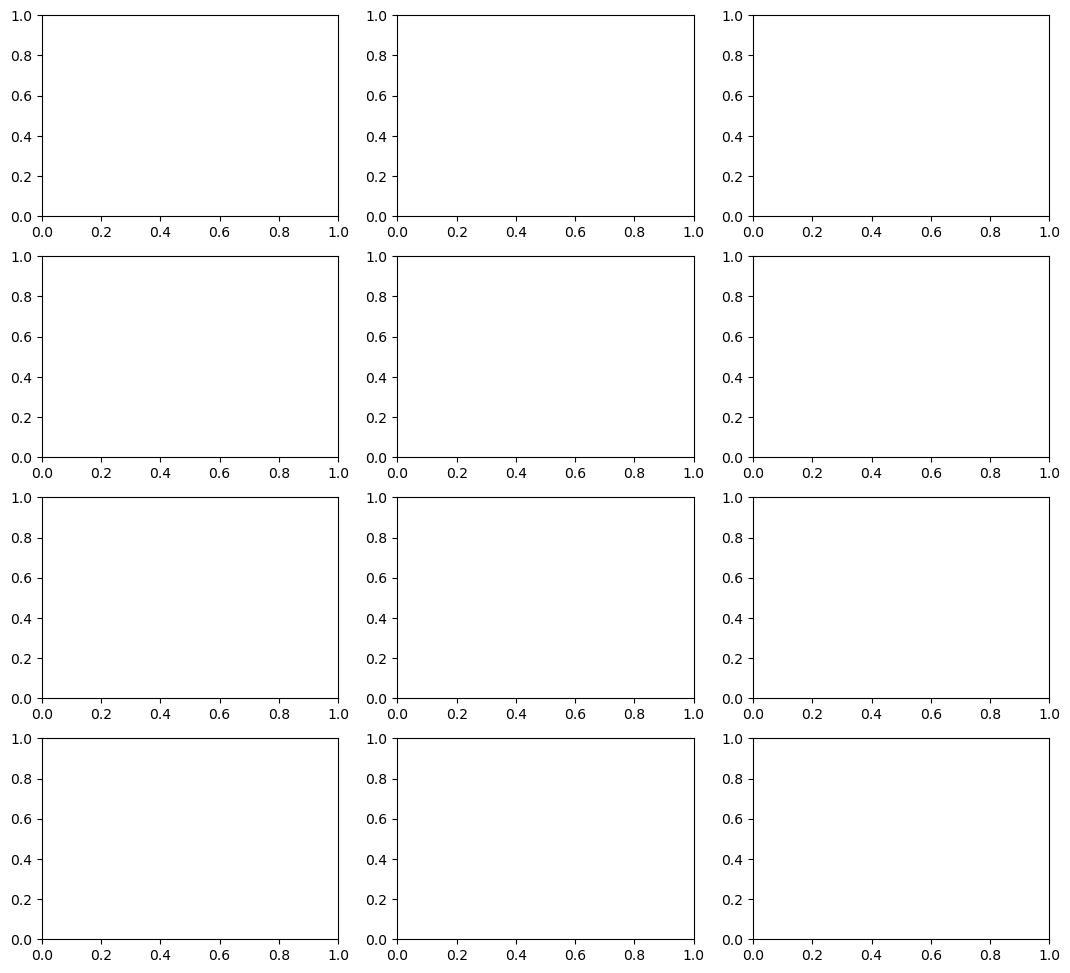

In [123]:
# Run grid evaluator on first GMM grid search results

grid_evaluator(gmm_grid_builds)

In [117]:
# Save first GMM grid search on builds as a csv

save_grid_results_csv(
    results_df=gmm_grid_builds,
    param_grid=grid_gmm_small,
    filename = "/BUILDS/01_gmm_grid_results_builds.csv"
)

Saved grid results to: C:/Users/emshe/Desktop/BRAINSTATION/CAPSTONE/GIT_REPO/DATA/RESULTS//BUILDS/01_gmm_grid_results_builds.csv


#### Demolitions

#### Renovations

In [125]:
# Choose a starter parameter grid for renos

grid_gmm_renos_01 = {
    "gmm__n_components": [2,3,4,5,7,10],
    "gmm__covariance_type": ["diag", "full"],
    "gmm__reg_covar": [1e-6, 1e-4],
    "gmm__n_init": [3],  # keep low for speed
    "prep__text__tfidf__max_features": [500],   # keep vocab modest
    "prep__text__svd__n_components": [2,4,6,10,20], # compact embeddings
}


In [ ]:
# Run starter GMM grid search on renos df

gmm_grid_results_renos_01 = run_cluster_grid(gmm_pipeline, cluster_renos_df, grid_gmm_renos_01)



[1/120] {'gmm__covariance_type': 'diag', 'gmm__n_components': 2, 'gmm__n_init': 3, 'gmm__reg_covar': 1e-06, 'prep__text__svd__n_components': 2, 'prep__text__tfidf__max_features': 500} | sil=0.3143  CH=2734.7  DB=1.327  Ine=NA  BIC=-316483  AIC=-316797  LL=20.120  runtime=0.53min


[2/120] {'gmm__covariance_type': 'diag', 'gmm__n_components': 2, 'gmm__n_init': 3, 'gmm__reg_covar': 1e-06, 'prep__text__svd__n_components': 4, 'prep__text__tfidf__max_features': 500} | sil=0.2275  CH=1794.2  DB=1.740  Ine=NA  BIC=-272669  AIC=-273039  LL=17.343  runtime=0.48min


[3/120] {'gmm__covariance_type': 'diag', 'gmm__n_components': 2, 'gmm__n_init': 3, 'gmm__reg_covar': 1e-06, 'prep__text__svd__n_components': 6, 'prep__text__tfidf__max_features': 500} | sil=0.1983  CH=1475.1  DB=1.972  Ine=NA  BIC=-230192  AIC=-230618  LL=14.650  runtime=0.51min


[4/120] {'gmm__covariance_type': 'diag', 'gmm__n_components': 2, 'gmm__n_init': 3, 'gmm__reg_covar': 1e-06, 'prep__text__svd__n_components': 10, 'prep__

## Hierarchical (Agglomerative) Clustering

### Agglomerative Clustering Pipeline Set up

In [ ]:
agglom_pipe = Pipeline(steps=[
    ("prep", preprocess),
    # Toggle this to Normalizer() when using cosine metrics; keep as passthrough for Euclidean/Ward.
    ("norm", "passthrough"),
    ("cluster", AgglomerativeClustering(
        n_clusters=10,              # will be tuned
        linkage="ward",             # default; will be tuned
        metric="euclidean",         # ignored for ward; will be tuned for non-ward
        compute_distances=True      # enables dendrogram plotting later
    ))
])

### Grid Searches

#### Builds

#### Demolitions

#### Renovations

## Clustering with HDBSCAN

### HDBSCAN Pipeline Set up

### Grid Searches

#### Builds

#### Demolitions

#### Renovations

## Hyperparameter Optimization Set Up

In [ ]:
# Define a function to evaluate full clustering pipeline once (updated to change metrics based on algorithm)

def evaluate_pipeline_once(est, df):
    """
    Fit full clustering pipeline on df and return a metrics dict.

    Always returns keys:
      inertia, silhouette, calinski_harabasz, davies_bouldin, 
      aic, bic, avg_loglik, fit_time_s, n_clusters_found
    (Unavailable metrics are NaN.)
    """
    t0 = time.time()
    est.fit(df)
    fit_time = time.time() - t0

    # Steps
    prep = est.named_steps.get("prep", None)
    final_est = est.steps[-1][1]  # last step (kmeans, gmm, agg, dbscan, ...)

    # Data in model space
    Z = prep.transform(df) if prep is not None else df

    # Labels: prefer .labels_, else .predict
    if hasattr(final_est, "labels_"):
        y = final_est.labels_
    elif hasattr(final_est, "predict"):
        y = final_est.predict(Z)
    else:
        y = None

    # Choose silhouette metric based on estimator's own metric/affinity when available
    # - KMeans/GMM: default 'euclidean'
    # - Agglomerative: use .metric
    # - DBSCAN: use .metric if set; if 'precomputed', skip silhouette
    sil_metric = "euclidean"
    if hasattr(final_est, "metric") and getattr(final_est, "metric") is not None:
        sil_metric = getattr(final_est, "metric")

    # Count clusters (for DBSCAN, exclude noise label -1)
    if y is not None:
        if np.any(y == -1):
            n_labels = len(np.unique(y[y != -1]))
        else:
            n_labels = len(np.unique(y))
    else:
        n_labels = 0

    res = {
        "inertia": np.nan,
        "silhouette": np.nan,
        "calinski_harabasz": np.nan,
        "davies_bouldin": np.nan,
        "aic": np.nan,
        "bic": np.nan,
        "avg_loglik": np.nan,   # Mean log-likelihood per sample if available
        "fit_time_s": fit_time,
        "n_clusters_found": n_labels,
    }

    # Inertia (K-Means style)
    if hasattr(final_est, "inertia_"):
        res["inertia"] = float(final_est.inertia_)

    # --- Hard-label metrics (silhouette/CH/DB) ---
    # For DBSCAN (which uses -1 for noise), compute on non-noise only.
    if y is not None:
        mask = (y != -1) if np.any(y == -1) else np.ones_like(y, dtype=bool)
        y_eval = y[mask]
        Z_eval = Z[mask] if hasattr(Z, "__getitem__") else Z

        # Skip if fewer than 2 clusters or not enough samples
        if (len(y_eval) > 0) and (len(np.unique(y_eval)) >= 2) and (getattr(Z_eval, "shape", (len(y_eval), 0))[0] > len(np.unique(y_eval))):
            # Silhouette (only if we have a usable metric)
            if sil_metric != "precomputed":
                try:
                    res["silhouette"] = float(silhouette_score(Z_eval, y_eval, metric=sil_metric))
                except Exception:
                    # Fallback to euclidean if chosen metric not supported on this data
                    try:
                        res["silhouette"] = float(silhouette_score(Z_eval, y_eval, metric="euclidean"))
                    except Exception:
                        pass

            # CH/DB are defined w.r.t. Euclidean geometry in sklearn implementations
            try:
                res["calinski_harabasz"] = float(calinski_harabasz_score(Z_eval, y_eval))
            except Exception:
                pass
            try:
                res["davies_bouldin"] = float(davies_bouldin_score(Z_eval, y_eval))
            except Exception:
                pass

    # Likelihood-based metrics (GMM)
    if hasattr(final_est, "aic") and hasattr(final_est, "bic"):
        try:
            res["aic"] = float(final_est.aic(Z))
            res["bic"] = float(final_est.bic(Z))
        except Exception:
            pass
    if hasattr(final_est, "score"):
        try:
            res["avg_loglik"] = float(final_est.score(Z))
        except Exception:
            pass

    return res


In [105]:
# Define function to run grid search for clustering pipeline

def run_cluster_grid(base_pipeline, df, grid):
    
    """
    Runs a parameter grid over any clustering pipeline and returns a DataFrame
    with params + metrics
    """
    
    grid_start = time.time()
    results = []

    grid_list = list(ParameterGrid(grid))
    total = len(grid_list)

    for i, params in enumerate(grid_list, start=1):
        
        est = clone(base_pipeline).set_params(**params)
        metrics = evaluate_pipeline_once(est, df)
        row = {**params, **metrics}
        results.append(row)

        # Build a safe, compact status line using available metrics
        def f(key, fmt):
            v = metrics.get(key, np.nan)
            return fmt.format(v) if (v is not None and not np.isnan(v)) else "NA"

        print(
            f"\n\n[{i}/{total}] {params} | "
            f"sil={f('silhouette','{:.4f}')}  "
            f"CH={f('calinski_harabasz','{:.1f}')}  "
            f"DB={f('davies_bouldin','{:.3f}')}  "
            f"Ine={f('inertia','{:.1f}')}  "
            f"BIC={f('bic','{:.0f}')}  "
            f"AIC={f('aic','{:.0f}')}  "
            f"LL={f('avg_loglik','{:.3f}')}  "
            f"runtime={metrics['fit_time_s']/60:.2f}min"
        )

    grid_elapsed = time.time() - grid_start
    print(f"\n\nFull grid search runtime: {grid_elapsed/60:.2f} minutes.")
    return pd.DataFrame(results).reset_index(drop=True)

## Grid Search Interpretation Tools

In [114]:
# Define function to save grid search results csv

def save_grid_results_csv(results_df, param_grid, 
                          filepath = "C:/Users/emshe/Desktop/BRAINSTATION/CAPSTONE/GIT_REPO/DATA/RESULTS",
                          filename = "grid_search_results",
                             title = "Grid search results"):
    
    """
    Save a CSV with the parameter grid written at the top, followed by the grid search results DataFrame
    """

    filepath = filepath + '/' + filename
    
    # Build header as proper CSV rows
    header_lines = []
    header_lines.append([title])
    header_lines.append([f"Timestamp: {datetime.now().isoformat(timespec='seconds')}"])
    header_lines.append(["Parameter Grid:"])
    for k in sorted(param_grid.keys()):
        v = param_grid[k]
        # param name in col A, empty col B, values in col C
        header_lines.append([k, "", json.dumps(v)])
    header_lines.append([])  # blank line before the DataFrame

    # Write header + DataFrame to one CSV file
    with open(filepath, "w", encoding="utf-8", newline="") as f:
        writer = csv.writer(f)
        writer.writerows(header_lines)
        results_df.to_csv(f, index=False)

    print(f"Saved grid results to: {filepath}")

In [ ]:
# Define function to read grid search results csv as a dataframe

def read_grid_results_csv(folder,
                          name,
                          filepath = "C:/Users/emshe/Desktop/BRAINSTATION/CAPSTONE/GIT_REPO/DATA/RESULTS", 
                          skiprows = 7):
   
    """
    Read a grid search results CSV (with metadata in the first rows).
    """

    full_path = f"{filepath}/{folder}/{name}"
    
    # Peek through file until we find the header row of the results
    with open(full_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    header_row = None
    for i, line in enumerate(lines):
        # detect by presence of known column names
        if "inertia" in line and "silhouette" in line:
            header_row = i
            break

    if header_row is None:
        raise ValueError("Could not detect the results table header in the file.")

    # Now read with skiprows = header_row
    df = pd.read_csv(full_path, skiprows=header_row)

    return df

In [ ]:
# Define function to extract list of all tested combos 

def list_tested_param_combos(
    results_df: pd.DataFrame,
    model: str = "kmeans") -> pd.DataFrame:
    
    """
    Return a neat table of all unique parameter combinations that were tested,
    with a 'trials' column indicating how many times each combo appeared.
    """

    # --- Pick defaults based on model ---
    if model == "kmeans":
        param_cols = (
            "kmeans__n_clusters",
            "prep__text__svd__n_components",
            "prep__text__tfidf__max_features",
        )
    elif model == "gmm":
        param_cols = (
            "gmm__n_components",
            "gmm__covariance_type",
            "gmm__reg_covar",
            "gmm__n_init",
            "prep__text__svd__n_components",
            "prep__text__tfidf__max_features",
        )
    elif model == 'agg':
        param_cols = (
            "agg__n_clusters",
            "agg__linkage",
            "agg__metric",        
            "prep__text__svd__n_components",
            "prep__text__tfidf__max_features",
        )
    elif model == "dbscan":
        param_cols = (
            "dbscan__eps",
            "dbscan__min_samples",
            "prep__text__svd__n_components",
            "prep__text__tfidf__max_features",
        )
        
    df = results_df.copy()

    # Collect parameter columns
    subset_cols = [c for c in param_cols if c in df.columns]

    # Convert numeric-like params to numeric; leave categorical as-is
    categorical_cols = {
        "gmm__covariance_type", "agg__linkage", "agg__metric"
    }
    for c in subset_cols:
        if c not in categorical_cols:
            df[c] = pd.to_numeric(df[c])

    combos = (
        df.dropna(subset=subset_cols)
          .groupby(subset_cols, as_index=False)
          .size()
          .rename(columns={"size": "trials"})
          .sort_values(subset_cols)
          .reset_index(drop=True)
    )

    # Cast integer-like floats to int for pretty printing
    for c in subset_cols:
        if pd.api.types.is_float_dtype(combos[c]) and (combos[c] % 1 == 0).all():
            combos[c] = combos[c].astype(int)

    print(f"{len(combos)} unique parameter combinations found.")
    return combos

In [ ]:
# Define function to check optimal parameter combo according to each metric

def print_top_configs(results_df, top_k = 1,
                      model = 'kmeans'):
    
    """
    Print the top parameter combos according to each metric in results_df
    """
    
    # Defaults by model
    if model == "kmeans":
        metric_cols = ("silhouette", "calinski_harabasz", "davies_bouldin", "inertia")
    elif model == "gmm":
        metric_cols = ("bic", "aic", "avg_loglik", "silhouette", "calinski_harabasz", "davies_bouldin")
    elif model in ("agg", "agglomerative"):
        metric_cols = ("silhouette", "calinski_harabasz", "davies_bouldin")
    elif model == "dbscan":
        metric_cols = ("silhouette", "calinski_harabasz", "davies_bouldin")

    # Which direction is better for each metric?
    higher_better = {
        "silhouette": True,
        "calinski_harabasz": True,
        "davies_bouldin": False,
        "inertia": False,
        "aic": False,
        "bic": False,
        "avg_loglik": True,
    }

    # Columns that are *not* params (we won't print them as params)
    non_param_cols = set(metric_cols) | {"fit_time_s", "n_clusters_found", "index"}

    # Auto-detect param columns
    param_cols = [c for c in results_df.columns if c not in non_param_cols]

    print("\n=== Top parameter configurations by metric ===")
    
    for m in metric_cols:
        dfm = results_df.dropna(subset=[m]).copy()
        asc = not higher_better.get(m, True)  # lower is better -> ascending True
        top = dfm.sort_values(m, ascending=asc).head(top_k)

        print(f"\nMetric: {m}  ({'higher' if not asc else 'lower'} is better)")
        for i, row in top.iterrows():
            params_str = ", ".join(f"{p}={row[p]}" for p in param_cols)
            fit_min = (row.get("fit_time_s", float('nan')) or float('nan')) / 60
            print(f"  • {m}={row[m]:.4f}  | {params_str}  | time={fit_min:.2f} min")

In [ ]:
# Define function to plot metric trends after grid search

def plot_metric_trends(results_df, model = 'kmeans'):
    """
    Plot average metrics vs each tuned parameter.
    """

    if model == "kmeans":
        metric_cols = ["silhouette", "calinski_harabasz", "davies_bouldin", "inertia"]
        param_cols  = ["kmeans__n_clusters",
                       "prep__text__tfidf__max_features",
                       "prep__text__svd__n_components"]

    elif model == "gmm":
        metric_cols = ["bic", "aic", "avg_loglik", "silhouette", "calinski_harabasz", "davies_bouldin"]
        param_cols  = ["gmm__n_components",
                       "prep__text__tfidf__max_features",
                       "prep__text__svd__n_components"]

    elif model == "agg":
        metric_cols = ["silhouette", "calinski_harabasz", "davies_bouldin"]
        param_cols  = ["agg__n_clusters",
                       "agg__linkage",
                       "agg__metric",
                       "prep__text__tfidf__max_features",
                       "prep__text__svd__n_components"]

    elif model == "dbscan":
        metric_cols = ["silhouette", "calinski_harabasz", "davies_bouldin"]
        param_cols  = ["dbscan__eps",
                       "dbscan__min_samples",
                       "prep__text__tfidf__max_features",
                       "prep__text__svd__n_components"]

    # Keep only those that actually exist in the df
    metric_cols = [m for m in metric_cols if m in results_df.columns]
    param_cols  = [p for p in param_cols if p in results_df.columns]
    
    n_rows = len(metric_cols)
    n_cols = len(param_cols)

    # increase vertical size to give rows more breathing room
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 12), squeeze=False)

    metric_notes = {
        "silhouette": "(higher is better)",
        "calinski_harabasz": "(higher is better)",
        "davies_bouldin": "(lower is better)",
        "inertia": "(lower is better)",
        "aic": "(lower is better)",
        "bic": "(lower is better)",
        "avg_loglik": "(higher is better)",
    }
    
    for r, metric in enumerate(metric_cols):
        for c, param in enumerate(param_cols):
            ax = axes[r, c]

            if param not in results_df.columns or metric not in results_df.columns:
                ax.set_visible(False)
                continue

            gp = (results_df[[param, metric]]
                  .dropna()
                  .groupby(param, as_index=False)
                  .mean())

            if gp.empty:
                ax.set_visible(False)
                continue

            # numeric x if possible; else treat as categorical
            try:
                gp[param] = pd.to_numeric(gp[param])
                gp = gp.sort_values(param)
                xvals = gp[param]
            except Exception:
                gp[param] = gp[param].astype(str)
                gp = gp.sort_values(param)
                xvals = gp[param]

            ax.plot(xvals, gp[metric], marker='o', linewidth=1.8)
            ax.grid(True, alpha=0.3)

            if r == 0:
                ax.set_title(param, fontsize=11)

            if c == 0:
                # 2-line vertical y-label: metric on line 1, note on line 2
                note = metric_notes.get(metric, "")
                ax.set_ylabel(f"{metric}\n{note}", fontsize=10, rotation=90,
                              va="center", ha="center")
                ax.yaxis.labelpad = 18  # add some space from tick labels

            ax.set_xlabel("")

    fig.suptitle("Grid Search: Average Metrics vs Tuned Parameters", fontsize=13, y=1.02)
    plt.show()


In [ ]:
# Define function to print 3D scatter plot of grid search

def plot_grid_3d_metric(results_df,
                        metric,
                        model = "kmeans"):
    """
    3D Plotly scatter of grid search results
    """

    # Choose default param columns by model
    x_col = "prep__text__tfidf__max_features"
    y_col = "prep__text__svd__n_components"
    
    if model == "kmeans":
        z_col = "kmeans__n_clusters"
    elif model == "gmm":
        z_col = "gmm__n_components"
    elif model in ("agg", "agglomerative"):
        z_col = "agg__n_clusters"
    elif model == "dbscan":
        z_col = "dbscan__min_samples"
    else:
        # fallback: first available
        for cand in ["kmeans__n_clusters","gmm__n_components","agg__n_clusters","dbscan__min_samples"]:
            if cand in results_df.columns:
                z_col = cand
                break
        else:
            raise ValueError("No suitable z-axis parameter column found.")
    
    param_cols = (x_col, y_col, z_col)

    # Basic checks
    missing = [c for c in (x_col, y_col, z_col, metric) if c not in results_df.columns]
    if missing:
        raise ValueError(f"Missing required column(s): {missing}")

    df = results_df.dropna(subset=[metric]).copy()

    # Keep originals for hover
    df["_x_orig"] = df[x_col]
    df["_y_orig"] = df[y_col]
    df["_z_orig"] = df[z_col]

    # Simple min–max scaling
    for src, dst in [(x_col, "x_scaled"), (y_col, "y_scaled"), (z_col, "z_scaled")]:
        s = pd.to_numeric(df[src], errors="coerce")
        lo, hi = s.min(), s.max()
        denom = (hi - lo) if pd.notna(hi) and pd.notna(lo) else np.nan
        if pd.isna(denom) or denom == 0:
            df[dst] = 0.0  # flat axis if only one value
        else:
            df[dst] = (s - lo) / denom

    # Metric direction (for colorscale)
    higher_better = {
        "silhouette": True,
        "calinski_harabasz": True,
        "davies_bouldin": False,
        "inertia": False,
        "aic": False,
        "bic": False,
        "avg_loglik": True,
    }
    hb = higher_better.get(metric, True)
    colorscale = "Viridis" if hb else "Viridis_r"

    # axis label map
    axis_labels = {
        "prep__text__tfidf__max_features": "tfidf_feats",
        "prep__text__svd__n_components": "svd_comp",
        "kmeans__n_clusters": "n_clusters",
        "gmm__n_components": "n_components",
        "agg__n_clusters": "n_clusters",
        "dbscan__min_samples": "min_samples",
    }

    fig = px.scatter_3d(
        df,
        x="x_scaled", y="y_scaled", z="z_scaled",
        color=metric,
        color_continuous_scale=colorscale,
        title=f"Grid Search 3D: {metric} ({'higher' if hb else 'lower'} is better)",
        hover_data={
            metric: ':.4f',
            x_col: True, y_col: True, z_col: True,
            "_x_orig": False, "_y_orig": False, "_z_orig": False,
        },
        opacity=0.85
    )

    fig.update_traces(marker=dict(size=4))
    fig.update_layout(
        scene=dict(
            xaxis=dict(title=axis_labels.get(x_col, x_col), range=[0, 1]),
            yaxis=dict(title=axis_labels.get(y_col, y_col), range=[0, 1]),
            zaxis=dict(title=axis_labels.get(z_col, z_col), range=[0, 1]),
        ),
        coloraxis_colorbar=dict(title=metric)
    )
    return fig



In [ ]:
# Define function to run all grid search interpretation tools

def grid_evaluator(results_df,
                   model="kmeans",
                   run_print=True,
                   run_trends=True,
                   run_3d=True,
                   sleep_sec=2.0):
    
    """
    Run a subset of grid interpretation utilities
    """

  # Choose metrics & params by model 
    if model == "kmeans":
        metrics = ["silhouette", "calinski_harabasz", "davies_bouldin", "inertia"]
        param_cols = ["kmeans__n_clusters",
                      "prep__text__tfidf__max_features",
                      "prep__text__svd__n_components"]

    elif model == "gmm":
        metrics = ["bic", "aic", "avg_loglik", "silhouette", "calinski_harabasz", "davies_bouldin"]
        param_cols = ["gmm__n_components",
                      "gmm__covariance_type",
                      "prep__text__tfidf__max_features",
                      "prep__text__svd__n_components"]

    elif model in ("agg", "agglomerative"):
        metrics = ["silhouette", "calinski_harabasz", "davies_bouldin"]
        param_cols = ["agg__n_clusters",
                      "agg__linkage",
                      "agg__metric",
                      "prep__text__tfidf__max_features",
                      "prep__text__svd__n_components"]

    elif model == "dbscan":
        metrics = ["silhouette", "calinski_harabasz", "davies_bouldin"]
        param_cols = ["dbscan__eps",
                      "dbscan__min_samples",
                      "prep__text__tfidf__max_features",
                      "prep__text__svd__n_components"]
    else:
        metric_candidates = ["bic","aic","avg_loglik","silhouette","calinski_harabasz","davies_bouldin","inertia"]
        param_candidates  = ["kmeans__n_clusters",
                             "gmm__n_components","gmm__covariance_type",
                             "agg__n_clusters","agg__linkage","agg__metric",
                             "dbscan__eps","dbscan__min_samples",
                             "prep__text__tfidf__max_features","prep__text__svd__n_components"]
        metrics = [m for m in metric_candidates if m in results_df.columns]
        param_cols = [p for p in param_candidates if p in results_df.columns]

    # Keep only columns that actually exist in the DF
    metrics   = [m for m in metrics   if m in results_df.columns]
    param_cols = [p for p in param_cols if p in results_df.columns]

    runtimes = {}
    start_all = time.time()

    if run_print:
        print("\n\nPrinting top parameter configurations by metric...\n")
        t0 = time.time()
        # Uses its own model-specific defaults; we pass model only
        print_top_configs(results_df, top_k=1, model=model)
        runtimes["Top parameter configs"] = (time.time() - t0) / 60

    if run_trends:
        print("\n\nPlotting metric trends vs tuned parameters...\n")
        t0 = time.time()
        plot_metric_trends(results_df, model=model)
        runtimes["Metric trend plots"] = (time.time() - t0) / 60

    if run_3d:
        if not metrics:
            print("\n\nNo metrics found to render in 3D; skipping.")
        else:
            print("\n\nRendering 3D metric views over the parameter grid...\n")
            t0 = time.time()
            for m in metrics:
                print(f"  - 3D plot for metric: {m}")
                # Let the 3D helper pick axes by model
                fig = plot_grid_3d_metric(results_df, metric=m, model=model)
                fig.show()
                time.sleep(sleep_sec)  # throttle Plotly renders
            runtimes["3D metric plots"] = (time.time() - t0) / 60

    total_min = (time.time() - start_all) / 60
    print("\n\n=== Step runtimes (minutes) ===")
    for name, mins in runtimes.items():
        print(f"- {name}: {mins:.2f} min")
    print(f"\nTotal runtime: {total_min:.2f} minutes.")